# Plotting a simple position plot for the jug1 data. 

This plot was used in a SCAR OSC 2026 poster. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import glob
import geopandas as gpd

## Load the txt data

This is the data collated by Andrew and stored in a single text file for each GNSS site. The locations are in lat lons. 


In [3]:
T1 = pd.read_fwf("../../data/flask/GNSS/first_season/TRACK_2024_336_343_sgp1.GEOD.jug1.txt", header = 0, skiprows = [1]).rename(columns={'Fract DOY': 'DOY'}).set_index('DOY')

T1 = gpd.GeoDataFrame(T1)
T1= T1.set_geometry(gpd.points_from_xy(T1['Longitude'], T1['Latitude']))
T1.set_crs(epsg=4326, inplace = True).to_crs(epsg = '3031', inplace=True)
T1

,*YY DOY,Seconds,Latitude,Longitude,Height,SigN,SigE,SigH,RMS,#,Atm,+-,Epoch,#BF,NotF,geometry
DOY,,,,,,,,,,,,,,,,
336.687847,2024 336,59429.999999,-65.793482,297.322704,401.2669,0.5,0.4,1.0,3.7,7,2196.47,11.80,1,16,1 K,POINT (-2370655.428 1224776.38)
336.688194,2024 336,59460.000000,-65.793482,297.322704,401.2669,0.5,0.4,1.0,4.2,7,2196.47,11.80,2,16,1 S,POINT (-2370655.428 1224776.38)
336.688542,2024 336,59490.000000,-65.793482,297.322704,401.2669,0.5,0.4,1.0,5.9,7,2196.47,11.80,3,16,1 S,POINT (-2370655.428 1224776.38)
336.688889,2024 336,59520.000000,-65.793482,297.322704,401.2669,0.5,0.3,1.0,7.7,7,2196.47,11.80,4,16,1 S,POINT (-2370655.428 1224776.38)
336.689236,2024 336,59550.000000,-65.793482,297.322704,401.2670,0.5,0.3,1.0,7.2,7,2196.48,11.80,5,16,1 S,POINT (-2370655.428 1224776.38)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343.598611,2024 343,51720.000000,-65.793481,297.322715,401.2583,0.3,0.2,0.6,5.5,9,2212.86,8.81,1725,20,2 S,POINT (-2370655.332 1224776.91)
343.598958,2024 343,51750.000000,-65.793481,297.322715,401.2583,0.3,0.2,0.6,7.0,9,2212.86,8.81,1726,20,2 S,POINT (-2370655.332 1224776.91)
343.599306,2024 343,51780.000000,-65.793481,297.322715,401.2583,0.3,0.2,0.6,6.5,9,2212.87,8.81,1727,20,2 S,POINT (-2370655.332 1224776.91)


In [4]:
doy = T1.index.to_numpy()
doy

array([336.68784722, 336.68819444, 336.68854167, ..., 343.59930556,
       343.59965278, 343.6       ], shape=(19788,))

## Plot

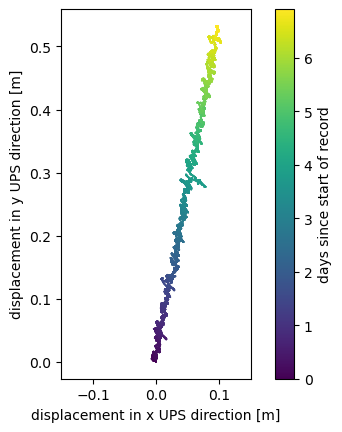

In [5]:

x = T1.get_coordinates()['x']
y = T1.get_coordinates()['y']


plt.scatter(x-x.iloc[0], y-y.iloc[0], c = doy-doy[0], s = 0.1)
plt.xlabel('displacement in x UPS direction [m]')
plt.ylabel('displacement in y UPS direction [m]')
plt.colorbar(label = 'days since start of record')
plt.gca().set_aspect('equal') 
plt.xlim([-0.15, 0.15]);
